In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
# Read the mhd file from data
from gecco.utils import write_run_all_script
import os

import mpl_interactions as pli
from gecco import patient_data
import gecco as fc
import numpy as np
from gecco.utils import nrrd_to_mhd, cropping_tool

Read the nrrd_file

In [50]:
# Number : [path, orientation, crop]

nrrd_files = {'0':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd',[1,0,2],[313,511,111,367,None,None]],
            '1':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd',[1,0,2],[313,511,111,367,None,None]],
            '2':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd',[1,0,2],[287,511,2,392,15,78]],
            '3':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd',[1,0,2],[254,None,None,None,None,None]],
            '4':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd',[2,1,0],[None,114,None,None,None,None]],
            '5':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd',[2,1,0],[None,72,None,None,None,None]],
            '6':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd',[2,1,0],[None,70,None,None,None,None]],
            '7':['/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd',[2,1,0],[None,70,None,None,None,None]]}


In [48]:
file_index = '7' # File index to load

Crop the nrrd file

In [49]:
cropping_tool(nrrd_file=nrrd_files[file_index][0],tr=nrrd_files[file_index][1]) # Center on center of bladder
tr = nrrd_files[file_index][1]
crop = nrrd_files[file_index][2]

interactive(children=(IntSlider(value=0, description='x_start', max=511), IntSlider(value=511, description='x_…

Write to mhd

In [45]:
nrrd_to_mhd(nrrd_files[file_index][0],force=True,tr=tr,crop=crop) # crop=[-200,None,None,None,None,None]

[2024-06-04 09:49:08,173] {utils.py:672} INFO - Directory /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2 already exists, but is being overwriten
[2024-06-04 09:49:08,174] {utils.py:677} INFO - Creating directory Pelvis_Prostate_Patient_2
[2024-06-04 09:49:08,815] {utils.py:763} INFO - Transposing the data
[2024-06-04 09:49:08,816] {utils.py:765} INFO - The spacing is [2.5   0.934 0.934]
[2024-06-04 09:49:08,816] {utils.py:767} INFO - The origin is [1469.5    -238.7905 -233.9077]
[2024-06-04 09:49:08,816] {utils.py:768} INFO - The shape is (263, 512, 512)
[2024-06-04 09:49:09,682] {utils.py:495} INFO - Loading density data from file
[2024-06-04 09:49:09,688] {utils.py:983} INFO -     Saved SchneiderMaterialsWeight1 atten to file in data/mu_over_rho/SchneiderMaterialsWeight1.csv
[2024-06-04 09:49:09,688] {utils.py:495} INFO - Loading density data from file
[2024-06-04 09:49:09,693] {utils.py:983} INFO -     Saved SchneiderMaterialsWeight2 atten to file in

/home/jericho/Software/gecco/gecco/spectrum.py:121: RuntimeWarning: divide by zero encountered in log
  log_y = np.log(yy)


[2024-06-04 09:49:10,382] {utils.py:795} INFO - Phantom Created
To load the phantom from the mhd file use the following command: 
phantom = patient_phantom.patient_phantom("/home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd",[nparticles])


Sample the phantom

In [46]:
phantom = patient_data.patient_phantom(nrrd_files[file_index][0], 1e6, force_materials=False, is_fullfan=False) #, reload=True, sim_num = 14)

[2024-06-04 09:49:10,556] {utils.py:185} INFO - Using default geometry, DSD = 1510, nDetector = [512, 512], dDetector = [0.784, 0.784]
[2024-06-04 09:49:10,557] {utils.py:495} INFO - Loading density data from file
[2024-06-04 09:49:10,558] {utils.py:551} INFO - Loading attenuation files from /home/jericho/Software/gecco/gecco/data/user_phantoms/Pelvis_Prostate_Patient_2/Pelvis_Prostate_Patient_2_materials.txt
[2024-06-04 09:49:10,558] {utils.py:552} INFO - Making attenuation files in gecco:
[2024-06-04 09:49:10,558] {utils.py:556} INFO -     Air atten file already exists, skipping...
[2024-06-04 09:49:10,559] {utils.py:556} INFO -     polyurethane atten file already exists, skipping...
[2024-06-04 09:49:10,559] {utils.py:556} INFO -     teflon atten file already exists, skipping...
[2024-06-04 09:49:10,559] {utils.py:556} INFO -     pmp atten file already exists, skipping...
[2024-06-04 09:49:10,559] {utils.py:556} INFO -     bone50 atten file already exists, skipping...
[2024-06-04 09

Plot one slice: Make sure it is axial

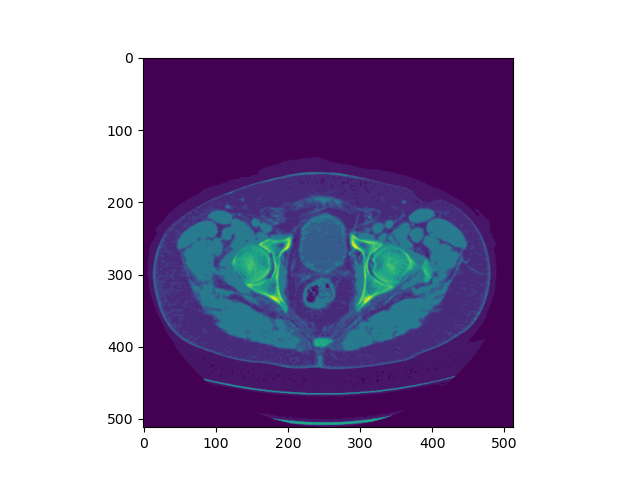

In [47]:
plt.figure()
plt.imshow(phantom.phantom[30,:,:])

## Write all the files

This is into a test directory

In [53]:
for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    test_file_name = nrrd[0].split('/')[-1].split('.')[0] + '_test.py'
    test_sim_dir = './test_python_scripts/'

    phantom.write_python_script_pelvis(os.path.join(test_sim_dir,test_file_name),tr=nrrd[1],crop=nrrd[2],nphoton=1e6,fast_mc_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),test_sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./test_python_scripts/run_all.sh

0 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-04 09:53:35,570] {utils.py:1020} INFO - Script written to run all Python files in the directory


## Write all files

This is to the run directory

In [56]:
for key,nrrd in nrrd_files.items():
    print(key + ' : ' + nrrd[0])

    file_name = nrrd[0].split('/')[-1].split('.')[0] + '.py'
    sim_dir = './python_scripts/'

    phantom.write_python_script_pelvis(os.path.join(sim_dir,file_name),tr=nrrd[1],crop=nrrd[2],nphoton=1e10,fast_mc_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')

# Combine the current working directory with the test_sim_dir
test_sim_dir_abs = os.path.join(os.getcwd(),sim_dir)
write_run_all_script(test_sim_dir_abs)

# Make the script executable
!chmod +x ./python_scripts/run_all.sh

0 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_1.nrrd
1 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_2.nrrd
2 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Female_Patient_3.nrrd
3 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_1.nrrd
4 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_2.nrrd
5 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_3.nrrd
6 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_4.nrrd
7 : /home/jericho/2-Datadir/Clinical_data/Pelvis/Pelvis_Prostate_Patient_5.nrrd
[2024-06-04 10:00:41,797] {utils.py:1020} INFO - Script written to run all Python files in the directory


In [ ]:
file_name = nrrd_file.split('/')[-1].split('.')[0] + '.py'
sim_dir = './python_scripts/'

write_run_all_script(sim_dir)
phantom.write_python_script_pelvis(os.path.join(sim_dir,file_name),tr=tr,crop=crop,nphoton=1e10,fast_mc_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC')